# Supplementary Figure 2


=== Participant-level 2IFC metacognition values ===
            Experiment Subject Condition  meta_da    da  M_ratio
          Experiment 1   00139        SC    1.038 2.310 0.449351
          Experiment 1   00139        CC    1.097 2.311 0.474686
          Experiment 1   00139        CI    1.103 1.815 0.607713
          Experiment 1   00173        SC    0.945 1.549 0.610071
          Experiment 1   00173        CC    1.498 1.344 1.114583
          Experiment 1   00173        CI    2.461 1.278 1.925665
          Experiment 1   00210        SC    1.889 1.298 1.455316
          Experiment 1   00210        CC    2.263 1.410 1.604965
          Experiment 1   00210        CI    1.439 1.416 1.016243
          Experiment 1   00212        SC    0.921 1.473 0.625255
          Experiment 1   00212        CC    1.366 1.170 1.167521
          Experiment 1   00212        CI    1.278 1.224 1.044118
          Experiment 1   00216        SC    1.191 1.546 0.770375
          Experiment 1   00216       

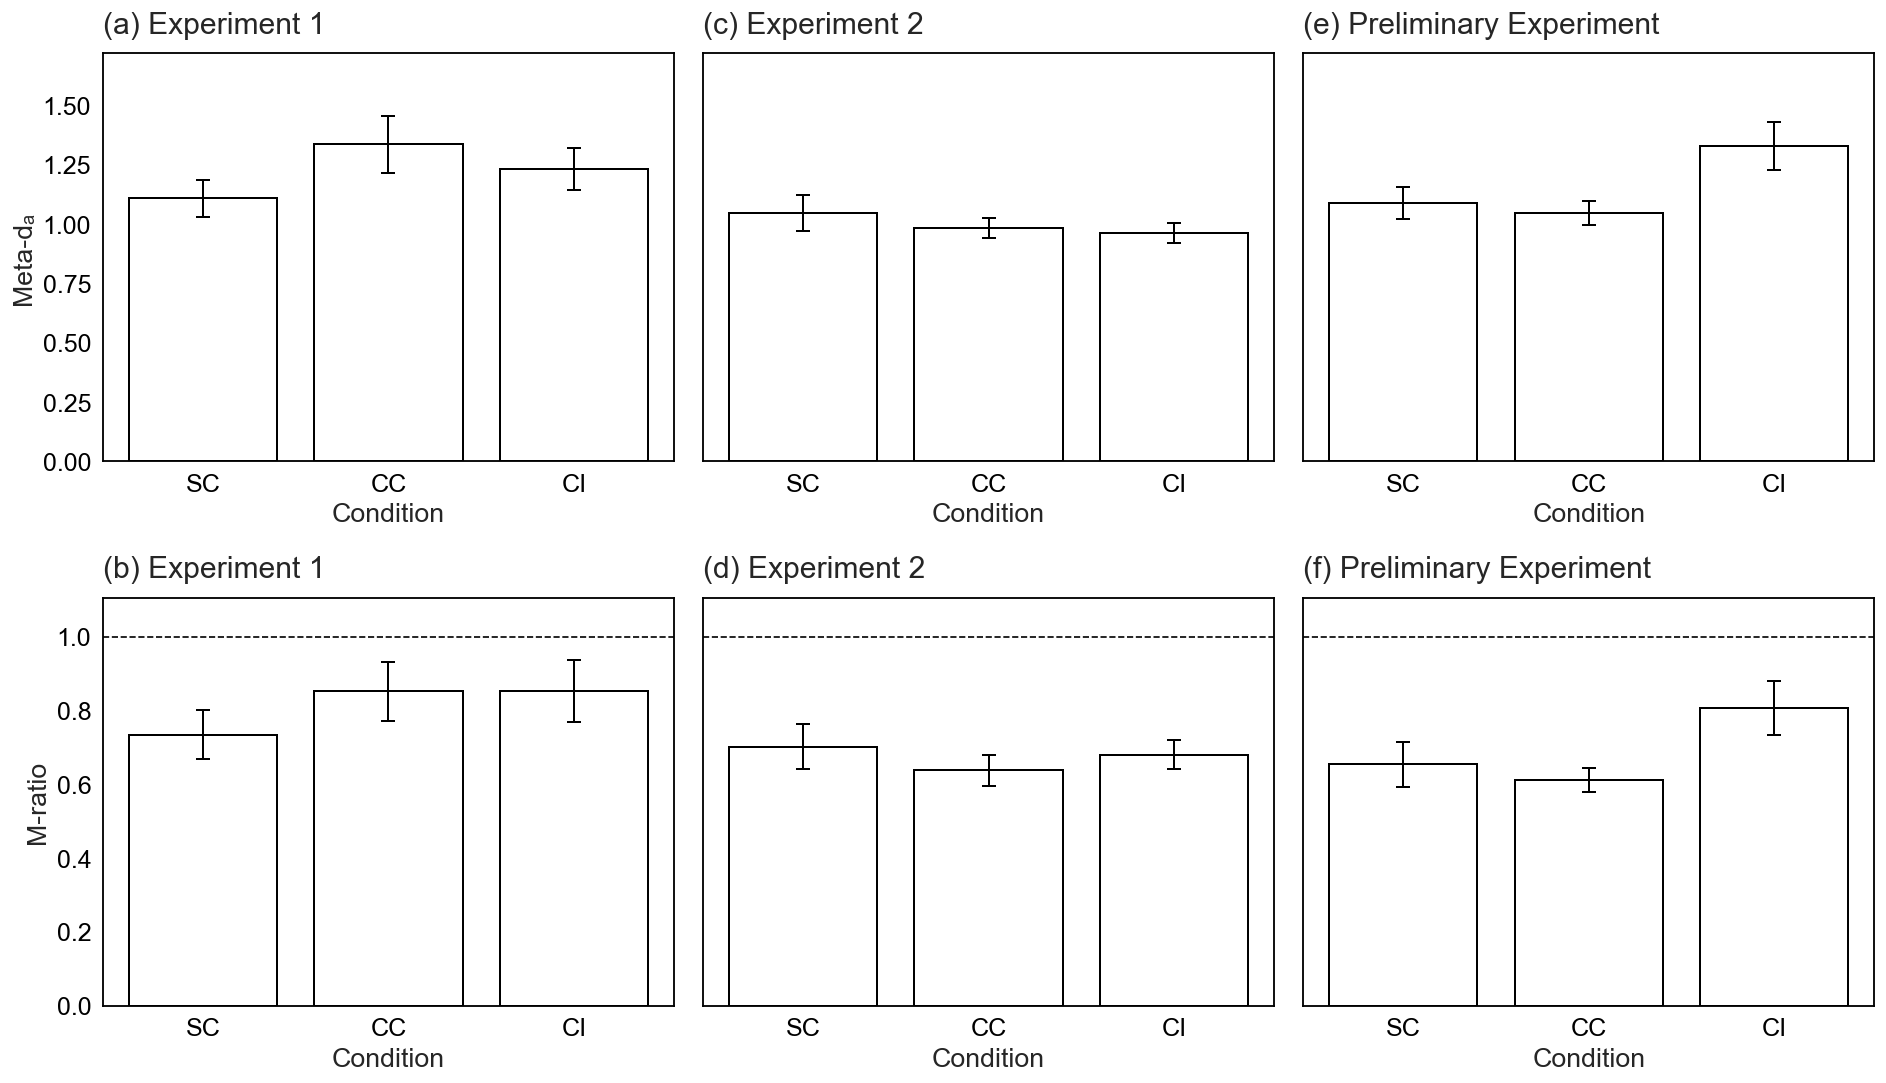


Saved participant-level values → /Users/w/Documents/GitHub/Blindsight_WM/results/cross_experiment/source_data/Supplementary_Figure_2_participant_data.csv
Saved mean / SD / SEM summary → /Users/w/Documents/GitHub/Blindsight_WM/results/cross_experiment/source_data/Supplementary_Figure_2_summary_data.csv
Saved figure → /Users/w/Documents/GitHub/Blindsight_WM/results/cross_experiment/figures/Supplementary_Figure_2_meta_da_mratio.png
CSV loaded from:
/Users/w/Documents/GitHub/Blindsight_WM/results/cross_experiment/source_data/Supplementary_Figure_2_participant_data.csv

Columns:
['Experiment', 'Subject', 'Condition', 'meta_da', 'da', 'M_ratio']

Experiments:
['Experiment 1' 'Experiment 2' 'Preliminary Experiment']

Number of participants per experiment:
Experiment
Experiment 1              16
Experiment 2              16
Preliminary Experiment    16
Name: Subject, dtype: int64



EXPERIMENT 1
N = 16 participants

----------------------------------------------------------------------
2IFC M

In [9]:
# ============================================================
# Supplementary Figure 2:
# Exp1–Prelim_Exp 2IFC meta-dₐ and M-ratio
#
# Top row:    meta-dₐ
# Bottom row: M-ratio
#
# Ordinary SEM across participants
# No participant markers
# Data source: saved {pid}_2ifc_meta.csv files
# ============================================================
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# Project paths
# =============================================================================

def find_project_root(start: Path | None = None) -> Path:
    """Locate the repository root from the current working directory."""
    start = (start or Path.cwd()).resolve()

    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir() and (candidate / "code").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the Blindsight_WM repository root."
    )

PROJECT_ROOT = find_project_root()

RESULTS_ROOT = PROJECT_ROOT / "results"

COMBINED_OUT = RESULTS_ROOT / "cross_experiment"
FIGURE_OUT = COMBINED_OUT / "figures"
STATISTICS_OUT = COMBINED_OUT / "statistics"
SOURCE_DATA_OUT = COMBINED_OUT / "source_data"

for directory in [
    COMBINED_OUT,
    FIGURE_OUT,
    STATISTICS_OUT,
    SOURCE_DATA_OUT,
]:
    directory.mkdir(parents=True, exist_ok=True)
    
# ============================================================
# 1. Experiment information
# ============================================================
EXPERIMENTS = [
    {
        "name": "Experiment 1",
        "key": "experiment_1",
        "participants": [
            "00139", "00173", "00210", "00212",
            "00216", "00217", "00218", "00219",
            "00220", "00222", "00223", "00224",
            "00225", "00226", "00227", "00228",
        ],
    },
    {
        "name": "Experiment 2",
        "key": "experiment_2",
        "participants": [
            "00024", "00030", "00074", "00081",
            "000087", "00089", "00091", "00093",
            "00094", "00096", "00097", "00098",
            "00099", "00100", "00102", "00105",
        ],
    },
    {
        "name": "Preliminary Experiment",
        "key": "preliminary_experiment",
        "participants": [
            "00003", "00038", "00051", "00052",
            "00054", "00060", "00061", "00068",
            "00071", "00130", "00161", "00162",
            "00193", "00200", "00201", "00202",
        ],
    },
]
cond_order = ['SC', 'CC', 'CI']


# ============================================================
# 2. Figure style
# ============================================================

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15
})

sns.set_style('white')


# ============================================================
# 3. Helper functions
# ============================================================

def format_axes(ax):
    """Apply the same axis style as the accuracy supplementary figure."""

    ax.grid(False)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.1)
        ax.spines[side].set_color('black')

    ax.tick_params(
        axis='both',
        colors='black'
    )


def get_condition_column(df):
    """Identify and standardize the condition column."""

    if 'Condition' in df.columns:
        return df

    if 'Unnamed: 0' in df.columns:
        return df.rename(
            columns={'Unnamed: 0': 'Condition'}
        )

    raise ValueError(
        'Condition column not found. '
        f'Available columns: {df.columns.tolist()}'
    )


def load_experiment_meta_data(experiment_key, participants):
    """
    Load participant-level 2IFC meta-d_a results generated by the
    experiment-specific analysis notebooks.
    """

    participant_out = (
        RESULTS_ROOT
        / experiment_key
        / "participant_summaries"
    )

    participant_dfs = []

    for pid in participants:
        file_path = (
            participant_out
            / pid
            / f"{pid}_2ifc_meta.csv"
        )

        if not file_path.is_file():
            raise FileNotFoundError(
                f"Missing participant summary: {file_path}\n"
                "Run the corresponding experiment analysis notebook first."
            )

        df = pd.read_csv(file_path)
        df.columns = df.columns.astype(str).str.strip()

        if "Condition" not in df.columns:
            df = df.rename(
                columns={df.columns[0]: "Condition"}
            )

        required_columns = {
            "Condition",
            "meta_da",
            "da",
        }

        missing_columns = required_columns.difference(df.columns)

        if missing_columns:
            raise KeyError(
                f"{file_path.name} is missing required columns: "
                + ", ".join(sorted(missing_columns))
            )

        df["Subject"] = pid

        participant_dfs.append(
            df[
                [
                    "Subject",
                    "Condition",
                    "meta_da",
                    "da",
                ]
            ].copy()
        )

    df_all = pd.concat(
        participant_dfs,
        ignore_index=True,
    )

    df_all["Condition"] = (
        df_all["Condition"]
        .astype(str)
        .str.strip()
    )

    df_all["meta_da"] = pd.to_numeric(
        df_all["meta_da"],
        errors="raise",
    )

    df_all["da"] = pd.to_numeric(
        df_all["da"],
        errors="raise",
    )

    if (df_all["da"] == 0).any():
        raise ZeroDivisionError(
            f"{experiment_key}: zero d_a found while calculating M-ratio."
        )

    df_all["M_ratio"] = (
        df_all["meta_da"]
        / df_all["da"]
    )

    df_all["Condition"] = pd.Categorical(
        df_all["Condition"],
        categories=cond_order,
        ordered=True,
    )

    return df_all


def calculate_summary(df, measure):
    """
    Calculate condition-wise group mean, SD, N, and ordinary SEM.

    SEM = SD across participants / sqrt(N)
    """

    summary = (
        df
        .dropna(subset=[measure])
        .groupby(
            'Condition',
            observed=True,
            as_index=False
        )
        .agg(
            mean=(measure, 'mean'),
            SD=(measure, 'std'),
            N=(measure, 'count')
        )
    )

    summary['SEM'] = (
        summary['SD']
        / np.sqrt(summary['N'])
    )

    summary['Condition'] = pd.Categorical(
        summary['Condition'],
        categories=cond_order,
        ordered=True
    )

    summary = (
        summary
        .sort_values('Condition')
        .reset_index(drop=True)
    )

    return summary


def plot_measure(
    ax,
    summary,
    panel_label,
    exp_name,
    ylabel,
    ylim,
    reference_line=None
):
    """Plot one measure using group means and ordinary SEM."""

    x = np.arange(len(cond_order))

    sns.barplot(
        data=summary,
        x='Condition',
        y='mean',
        order=cond_order,
        color='white',
        edgecolor='black',
        linewidth=1.2,
        errorbar=None,
        ax=ax
    )

    ax.errorbar(
        x=x,
        y=summary['mean'].to_numpy(dtype=float),
        yerr=summary['SEM'].to_numpy(dtype=float),
        fmt='none',
        ecolor='black',
        elinewidth=1.2,
        capsize=4,
        capthick=1.2,
        zorder=3
    )

    if reference_line is not None:
        ax.axhline(
            reference_line,
            linestyle='--',
            color='black',
            linewidth=1.0,
            zorder=0
        )

    ax.set_title(
        f'{panel_label} {exp_name}',
        loc='left',
        pad=12
    )

    ax.set_xlabel('Condition')
    ax.set_ylabel(ylabel)
    ax.set_ylim(ylim)

    format_axes(ax)


# ============================================================
# 4. Load and summarize all experiments
# ============================================================

all_data = []

for exp in EXPERIMENTS:

    df_meta = load_experiment_meta_data(
        exp['key'],
        exp['participants']
    )

    meta_summary = calculate_summary(
        df_meta,
        'meta_da'
    )

    mratio_summary = calculate_summary(
        df_meta,
        'M_ratio'
    )

    all_data.append({
        'name': exp['name'],
        'df': df_meta,
        'meta_summary': meta_summary,
        'mratio_summary': mratio_summary
    })


# ============================================================
# 5. Determine common y-axis ranges
# ============================================================

# Common Meta-dₐ scale across Experiments 1–3
all_meta_upper = []

for exp_data in all_data:
    summary = exp_data['meta_summary']

    all_meta_upper.extend(
        (
            summary['mean']
            + summary['SEM']
        ).dropna().tolist()
    )

if len(all_meta_upper) > 0:
    meta_upper_limit = max(all_meta_upper) * 1.18
else:
    meta_upper_limit = 1

meta_ylim = (
    0,
    meta_upper_limit
)


# Common M-ratio scale across Experiments 1–3
all_mratio_upper = []

for exp_data in all_data:
    summary = exp_data['mratio_summary']

    all_mratio_upper.extend(
        (
            summary['mean']
            + summary['SEM']
        ).dropna().tolist()
    )

if len(all_mratio_upper) > 0:
    mratio_upper_limit = max(
        1.05,
        max(all_mratio_upper) * 1.18
    )
else:
    mratio_upper_limit = 1.05

mratio_ylim = (
    0,
    mratio_upper_limit
)


# ============================================================
# 6. Plot 2 × 3 figure
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9.5),
    dpi=120,
    sharey='row'
)

axes = axes.flatten()

meta_axes = [0, 1, 2]
mratio_axes = [3, 4, 5]

meta_labels = ['(a)', '(c)', '(e)']
mratio_labels = ['(b)', '(d)', '(f)']


for i, exp_data in enumerate(all_data):

    # Top row: Meta-dₐ
    plot_measure(
        ax=axes[meta_axes[i]],
        summary=exp_data['meta_summary'],
        panel_label=meta_labels[i],
        exp_name=exp_data['name'],
        ylabel='Meta-dₐ',
        ylim=meta_ylim,
        reference_line=None
    )

    # Bottom row: M-ratio
    plot_measure(
        ax=axes[mratio_axes[i]],
        summary=exp_data['mratio_summary'],
        panel_label=mratio_labels[i],
        exp_name=exp_data['name'],
        ylabel='M-ratio',
        ylim=mratio_ylim,
        reference_line=1
    )


plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)


# ============================================================
# 7. Save participant-level data and SEM summaries
# ============================================================

figure_path = (
    FIGURE_OUT
    / "Supplementary_Figure_2_meta_da_mratio.png"
)

# Combine participant-level values
participant_level_all = pd.concat(
    [
        exp_data['df'].assign(
            Experiment=exp_data['name']
        )
        for exp_data in all_data
    ],
    ignore_index=True
)

participant_level_all = participant_level_all[
    [
        'Experiment',
        'Subject',
        'Condition',
        'meta_da',
        'da',
        'M_ratio'
    ]
].sort_values(
    [
        'Experiment',
        'Subject',
        'Condition'
    ]
)


# Combine summaries
summary_rows = []

for exp_data in all_data:

    meta_tmp = (
        exp_data['meta_summary']
        .copy()
        .assign(
            Experiment=exp_data['name'],
            Measure='Meta-dₐ'
        )
    )

    mratio_tmp = (
        exp_data['mratio_summary']
        .copy()
        .assign(
            Experiment=exp_data['name'],
            Measure='M-ratio'
        )
    )

    summary_rows.extend(
        [meta_tmp, mratio_tmp]
    )

summary_all = pd.concat(
    summary_rows,
    ignore_index=True
)

summary_all = summary_all[
    [
        'Experiment',
        'Measure',
        'Condition',
        'mean',
        'SD',
        'N',
        'SEM'
    ]
].sort_values(
    [
        'Experiment',
        'Measure',
        'Condition'
    ]
)

# Print values
print(
    '\n=== Participant-level 2IFC metacognition values ==='
)
print(
    participant_level_all.to_string(index=False)
)

print(
    '\n=== 2IFC meta-dₐ and M-ratio mean / SD / SEM ==='
)
print(
    summary_all.to_string(index=False)
)


# Save CSV files
participant_csv_path = (
    SOURCE_DATA_OUT
    / "Supplementary_Figure_2_participant_data.csv"
)

summary_csv_path = (
    SOURCE_DATA_OUT
    / "Supplementary_Figure_2_summary_data.csv"
)


participant_level_all.to_csv(
    participant_csv_path,
    index=False
)

summary_all.to_csv(
    summary_csv_path,
    index=False
)


# ============================================================
# 8. Save figure
# ============================================================

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    f'\nSaved participant-level values → '
    f'{participant_csv_path}'
)

print(
    f'Saved mean / SD / SEM summary → '
    f'{summary_csv_path}'
)

print(
    f'Saved figure → '
    f'{figure_path}'
)

# ============================================================
# Experiment 1, 2, Preliminary Experiment:
# One-way repeated-measures ANOVA
# 2IFC meta-dₐ and M-ratio
# ============================================================

import pandas as pd
import pingouin as pg


# ------------------------------------------------------------
# 1. Load the combined participant-level data
# ------------------------------------------------------------

# 위 figure 코드에서 방금 저장한 CSV 사용
csv_path = participant_csv_path

df_2ifc_all = pd.read_csv(
    csv_path,
    dtype={'Subject': str}
)

# Remove accidental spaces from column names
df_2ifc_all.columns = df_2ifc_all.columns.str.strip()

# Remove accidental spaces from labels
df_2ifc_all['Experiment'] = (
    df_2ifc_all['Experiment']
    .astype(str)
    .str.strip()
)

df_2ifc_all['Condition'] = (
    df_2ifc_all['Condition']
    .astype(str)
    .str.strip()
)

print('CSV loaded from:')
print(csv_path)

print('\nColumns:')
print(df_2ifc_all.columns.tolist())

print('\nExperiments:')
print(df_2ifc_all['Experiment'].unique())

print('\nNumber of participants per experiment:')
print(
    df_2ifc_all.groupby('Experiment')['Subject']
    .nunique()
)
# ------------------------------------------------------------
# 2. Function for printing pairwise comparisons
# ------------------------------------------------------------

def print_pairwise_results(result_df, title):

    print("\n" + title)

    preferred_columns = [
        "A",
        "B",
        "T",
        "dof",
        "p_unc",
        "p_corr",
        "p_adjust",
        "hedges"
    ]

    available_columns = [
        col for col in preferred_columns
        if col in result_df.columns
    ]

    print(result_df[available_columns].to_string(index=False))


# ------------------------------------------------------------
# 3. Function for running each dependent variable
# ------------------------------------------------------------

def run_rm_anova(df_exp, dv, measure_name):

    print("\n" + "-" * 70)
    print(measure_name)
    print("-" * 70)

    # Descriptive statistics
    descriptives = (
        df_exp.groupby("Condition")[dv]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    descriptives["sem"] = (
        descriptives["std"] /
        descriptives["count"] ** 0.5
    )

    print("\nDescriptive statistics")
    print(descriptives.to_string(index=False))


    # Repeated-measures ANOVA
    anova = pg.rm_anova(
        data=df_exp,
        dv=dv,
        within="Condition",
        subject="Subject",
        correction="auto",
        detailed=True,
        effsize="ng2",
    )
    print("\nRepeated-measures ANOVA")
    print(anova.to_string(index=False))


    # Bonferroni-corrected pairwise tests
    posthoc = pg.pairwise_tests(
        data=df_exp,
        dv=dv,
        within="Condition",
        subject="Subject",
        padjust="bonf",
        effsize="hedges"
    )

    print_pairwise_results(
        posthoc,
        "\nBonferroni-corrected pairwise comparisons"
    )

    return anova, posthoc, descriptives


# ------------------------------------------------------------
# 4. Run Experiment 1, 2, and 3 separately
# ------------------------------------------------------------

all_results = {}
experiment_order = [
    "Experiment 1",
    "Experiment 2",
    "Preliminary Experiment",
]

for exp in experiment_order:

    df_exp = df_2ifc_all[
        df_2ifc_all["Experiment"] == exp
    ].copy()

    print("\n\n")
    print("=" * 80)
    print(exp.upper())
    print("=" * 80)

    print(
        f"N = {df_exp['Subject'].nunique()} participants"
    )

    # Check that every participant has SC, CC, and CI
    condition_counts = (
        df_exp.groupby("Subject")["Condition"]
        .nunique()
    )

    incomplete_subjects = condition_counts[
        condition_counts < 3
    ]

    if len(incomplete_subjects) > 0:
        print("\nWarning: incomplete participants")
        print(incomplete_subjects)


    # meta-dₐ
    meta_results = run_rm_anova(
        df_exp=df_exp,
        dv="meta_da",
        measure_name="2IFC META-dₐ"
    )


    # M-ratio
    mratio_results = run_rm_anova(
        df_exp=df_exp,
        dv="M_ratio",
        measure_name="2IFC M-RATIO"
    )


    all_results[exp] = {
        "meta_da": {
            "anova": meta_results[0],
            "posthoc": meta_results[1],
            "descriptives": meta_results[2]
        },
        "M_ratio": {
            "anova": mratio_results[0],
            "posthoc": mratio_results[1],
            "descriptives": mratio_results[2]
        }
    }

# Supplementary Figure 3

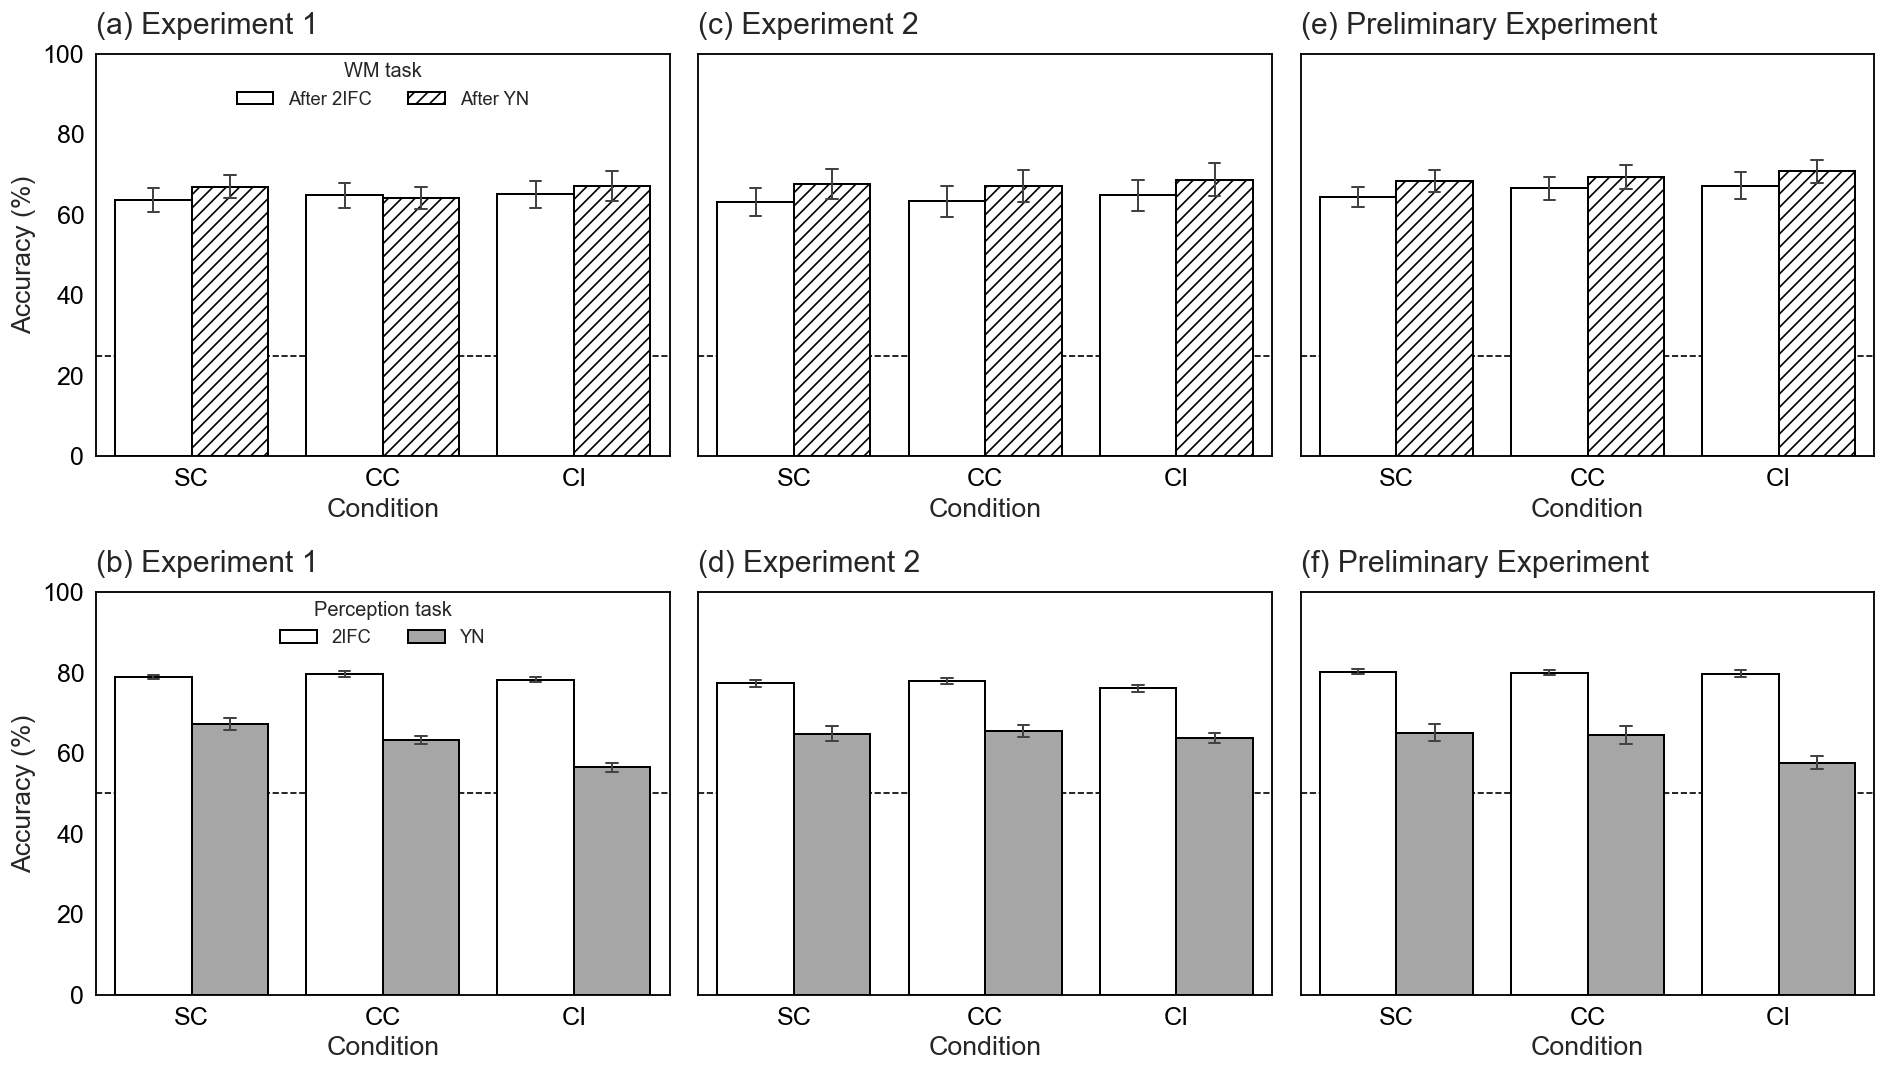


Saved participant-level values → /Users/w/Documents/GitHub/Blindsight_WM/results/cross_experiment/source_data/Supplementary_Figure_2_participant_data.csv
Saved mean / SD / SEM summary → /Users/w/Documents/GitHub/Blindsight_WM/results/cross_experiment/source_data/Supplementary_Figure_3_summary_data.csv
Saved figure → /Users/w/Documents/GitHub/Blindsight_WM/results/cross_experiment/figures/Supplementary_Figure_3_wm_perception_accuracy.png


In [15]:
# ============================================================
# Supplementary Figure 3. Experiment 1,2, Preliminary_experiment group summary: panels (a)–(f)
# ordinary SEM, no participant markers
# ============================================================
from pathlib import Path
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Project Path
# ============================================================

def find_project_root(start: Path | None = None) -> Path:
    """Locate the repository root from the current working directory."""
    start = (start or Path.cwd()).resolve()

    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir() and (candidate / "code").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the Blindsight_WM repository root."
    )

PROJECT_ROOT = find_project_root()

RESULTS_ROOT = PROJECT_ROOT / "results"

COMBINED_OUT = RESULTS_ROOT / "cross_experiment"
FIGURE_OUT = COMBINED_OUT / "figures"
STATISTICS_OUT = COMBINED_OUT / "statistics"
SOURCE_DATA_OUT = COMBINED_OUT / "source_data"

for directory in [
    COMBINED_OUT,
    FIGURE_OUT,
    STATISTICS_OUT,
    SOURCE_DATA_OUT,
]:
    directory.mkdir(parents=True, exist_ok=True)


# --------------------------------------------------
# Experiment info
# --------------------------------------------------

EXPERIMENTS = [
    {
        "name": "Experiment 1",
        "key": "experiment_1",
        "participants": [
            "00139", "00173", "00210", "00212",
            "00216", "00217", "00218", "00219",
            "00220", "00222", "00223", "00224",
            "00225", "00226", "00227", "00228",
        ],
    },
    {
        "name": "Experiment 2",
        "key": "experiment_2",
        "participants": [
            "00024", "00030", "00074", "00081",
            "000087", "00089", "00091", "00093",
            "00094", "00096", "00097", "00098",
            "00099", "00100", "00102", "00105",
        ],
    },
    {
        "name": "Preliminary Experiment",
        "key": "preliminary_experiment",
        "participants": [
            "00003", "00038", "00051", "00052",
            "00054", "00060", "00061", "00068",
            "00071", "00130", "00161", "00162",
            "00193", "00200", "00201", "00202",
        ],
    },
]

cond_order = ['SC', 'CC', 'CI']
phase_order = ['After 2IFC', 'After YN']
task_order = ['2IFC', 'YN']

# --------------------------------------------------
# Style
# --------------------------------------------------

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 11,
    'legend.title_fontsize': 12
})

sns.set_style("white")

palette_two = ['white', '0.65']

# --------------------------------------------------
# Helper functions
# --------------------------------------------------

def find_raw_files(data_dir, pid):
    """
    Return all raw CSV files for one participant.
    """
    return sorted(
        (data_dir / pid).glob(
            f"participant_{pid}_day*_block*.csv"
        )
    )
    
def format_axes(ax):
    ax.grid(False)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.1)
        ax.spines[side].set_color('black')

    ax.tick_params(axis='both', colors='black')

def load_experiment_data(experiment_key, participants):
    data_dir = PROJECT_ROOT / "data" / experiment_key
    wm_list = []
    acc_list = []

    for pid in participants:

        paths = find_raw_files(data_dir, pid)

        if not paths:
            print(f'Missing raw files for {pid}')
            continue

        df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
        df_raw.columns = df_raw.columns.str.strip()
        df_raw = df_raw.reset_index(drop=True)

        required_cols = {'Task', 'Category', 'Combined_Correct'}

        if not required_cols.issubset(df_raw.columns):
            print(f'Missing required columns in {pid}')
            continue

        # ------------------------------
        # WM probe accuracy
        # ------------------------------
        followed_by = []

        for i, row in df_raw.iterrows():
            if row['Task'] == 'WM_probe':
                followed_by.append(df_raw.loc[i - 1, 'Task'] if i > 0 else 'Unknown')
            else:
                followed_by.append(None)

        df_raw['FollowedBy'] = followed_by

        wm = df_raw[df_raw['Task'] == 'WM_probe'].copy()
        wm = wm[wm['FollowedBy'].isin(['2IFC', 'YN'])].copy()

        if not wm.empty:
            tmp_wm = (
                wm.groupby(['Category', 'FollowedBy'])['Combined_Correct']
                .mean()
                .reset_index()
            )

            tmp_wm['acc'] = pd.to_numeric(
                tmp_wm['Combined_Correct'],
                errors='coerce'
            ) * 100

            tmp_wm['Type'] = tmp_wm['FollowedBy'].map({
                '2IFC': 'After 2IFC',
                'YN': 'After YN'
            })

            tmp_wm['Subject'] = pid

            wm_list.append(tmp_wm[['Subject', 'Category', 'Type', 'acc']])

        # ------------------------------
        # 2IFC vs YN accuracy
        # ------------------------------
        sub = df_raw[df_raw['Task'].isin(['2IFC', 'YN'])].copy()

        if not sub.empty:
            tmp_acc = (
                sub.groupby(['Task', 'Category'])['Combined_Correct']
                .mean()
                .reset_index()
            )

            tmp_acc['acc'] = pd.to_numeric(
                tmp_acc['Combined_Correct'],
                errors='coerce'
            ) * 100

            tmp_acc['Subject'] = pid

            acc_list.append(tmp_acc[['Subject', 'Task', 'Category', 'acc']])

    if len(wm_list) == 0:
        raise RuntimeError(f'No WM probe data found in {data_dir}')

    if len(acc_list) == 0:
        raise RuntimeError(f'No task accuracy data found in {data_dir}')

    df_wm = pd.concat(wm_list, ignore_index=True)
    df_acc = pd.concat(acc_list, ignore_index=True)

    df_wm['Category'] = pd.Categorical(
        df_wm['Category'],
        categories=cond_order,
        ordered=True
    )

    df_wm['Type'] = pd.Categorical(
        df_wm['Type'],
        categories=phase_order,
        ordered=True
    )

    df_acc['Category'] = pd.Categorical(
        df_acc['Category'],
        categories=cond_order,
        ordered=True
    )

    df_acc['Task'] = pd.Categorical(
        df_acc['Task'],
        categories=task_order,
        ordered=True
    )

    return df_wm, df_acc


def plot_wm_accuracy(ax, df_wm, panel_label, exp_name, show_legend=False):
    sns.barplot(
        data=df_wm,
        x='Category',
        y='acc',
        hue='Type',
        order=cond_order,
        hue_order=phase_order,
        palette=['white', 'white'],
        edgecolor='black',
        linewidth=1.2,
        errorbar='se',
        capsize=0.12,
        err_kws={'linewidth': 1.2},
        ax=ax
    )
    bars = ax.patches
    n_cond = len(cond_order)

    for i, bar in enumerate(bars):
        hue_idx = i // n_cond

        if hue_idx == 1:   # After YN
            bar.set_hatch('///')
        else:
            bar.set_hatch('')
            
    ax.axhline(25, linestyle='--', color='black', linewidth=1.0, zorder=0)

    ax.set_title(f'{panel_label} {exp_name}', loc='left', pad=12)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    format_axes(ax)

    if show_legend:
        leg = ax.legend(
            title='WM task',
            loc='upper center',
            bbox_to_anchor=(0.5, 1.00),
            frameon=False,
            ncol=2
        )

        handles = leg.legend_handles
        handles[0].set_hatch('')
        handles[1].set_hatch('///')

    else:
        ax.get_legend().remove()


def plot_task_accuracy(ax, df_acc, panel_label, exp_name, show_legend=False):
    sns.barplot(
        data=df_acc,
        x='Category',
        y='acc',
        hue='Task',
        order=cond_order,
        hue_order=task_order,
        palette=palette_two,
        edgecolor='black',
        linewidth=1.2,
        errorbar='se',
        capsize=0.12,
        err_kws={'linewidth': 1.2},
        ax=ax
    )

    ax.axhline(50, linestyle='--', color='black', linewidth=1.0, zorder=0)

    ax.set_title(f'{panel_label} {exp_name}', loc='left', pad=12)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    format_axes(ax)

    if show_legend:
        ax.legend(
            title='Perception task',
            loc='upper center',
            bbox_to_anchor=(0.5, 1.00),
            frameon=False,
            ncol=2
        )
    else:
        ax.get_legend().remove()


# ==================================================
# Load data
# ==================================================

all_data = []

for exp in EXPERIMENTS:
    df_wm, df_acc = load_experiment_data(
        exp["key"],
        exp["participants"]
    )

    all_data.append({
        "name": exp["name"],
        "df_wm": df_wm,
        "df_acc": df_acc
    })
# ==================================================
# Plot 2 × 3 figure
# ==================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 9.5),
    dpi=120,
    sharey='row'
)
axes = axes.flatten()
wm_axes = [0, 1, 2]
acc_axes = [3, 4, 5]

wm_labels = ['(a)', '(c)', '(e)']
acc_labels = ['(b)', '(d)', '(f)']

for i, exp_data in enumerate(all_data):

    # Top row: WM probe accuracy
    plot_wm_accuracy(
        axes[wm_axes[i]],
        exp_data['df_wm'],
        wm_labels[i],
        exp_data['name'],
        show_legend=(i == 0)
    )

    # Bottom row: 2IFC vs YN accuracy
    plot_task_accuracy(
        axes[acc_axes[i]],
        exp_data['df_acc'],
        acc_labels[i],
        exp_data['name'],
        show_legend=(i == 0)
    )

for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.set_bbox_to_anchor((0.5, 1.02))
plt.tight_layout(rect=[0, 0, 1, 0.97])


summary_rows = []

for exp_data in all_data:
    wm_summary = (
        exp_data["df_wm"]
        .groupby(
            ["Category", "Type"],
            observed=False
        )["acc"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    wm_summary["sem"] = (
        wm_summary["std"]
        / np.sqrt(wm_summary["count"])
    )

    wm_summary["Experiment"] = exp_data["name"]
    wm_summary["Measure"] = "WM_accuracy"

    acc_summary = (
        exp_data["df_acc"]
        .groupby(
            ["Category", "Task"],
            observed=False
        )["acc"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    acc_summary["sem"] = (
        acc_summary["std"]
        / np.sqrt(acc_summary["count"])
    )

    acc_summary["Experiment"] = exp_data["name"]
    acc_summary["Measure"] = "Perception_accuracy"

    summary_rows.extend([
        wm_summary,
        acc_summary
    ])

summary_all = pd.concat(
    summary_rows,
    ignore_index=True,
    sort=False
)

summary_csv_path = (
    SOURCE_DATA_OUT
    / "Supplementary_Figure_3_summary_data.csv"
)

summary_all.to_csv(
    summary_csv_path,
    index=False
)

# ============================================================
# Save participant-level data and SEM summaries
# ============================================================

figure_path = (
    FIGURE_OUT
    / "Supplementary_Figure_3_wm_perception_accuracy.png"
)

# --------------------------------------------------
# Save
# --------------------------------------------------

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    f'\nSaved participant-level values → '
    f'{participant_csv_path}'
)

print(
    f'Saved mean / SD / SEM summary → '
    f'{summary_csv_path}'
)

print(
    f'Saved figure → '
    f'{figure_path}'
)

# rmANOVA: Experiment 1, 2, and Preliminary experiment

In [19]:
# =============================================================================
# Statistical analyses for Experiment 1, Experiment 2,
# and Preliminary Experiment
#
# Analyses
# -----------------------------------------------------------------------------
# 1) WM accuracy: Phase × Condition
# 2) Perceptual accuracy: Task × Condition
# 3) Detection sensitivity d_a: Task × Condition
#    + separate 2IFC and YN one-way rmANOVAs
# 4) Detection sensitivity ratio: YN d_a / 2IFC d_a
# 5) Scaled comparison: YN d_a vs 2IFC d_a / sqrt(2)
# 6) YN hit rate (HR) and false-alarm rate (FAR)
# 7) 2IFC staircase contrast
# 8) 2IFC and YN meta-d_a
# 9) Mauchly's sphericity checks for one-factor analyses
#
# Statistical conventions
# -----------------------------------------------------------------------------
# - Repeated-measures ANOVA: Pingouin
# - Greenhouse–Geisser correction when required
# - Pairwise tests: two-tailed paired tests
# - Pairwise correction: Bonferroni
# - Effect size: Hedges' g
# =============================================================================


# =============================================================================
# Imports
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import pingouin as pg


# =============================================================================
# Project paths
# =============================================================================

def find_project_root(start: Path | None = None) -> Path:
    """Locate the Blindsight_WM repository root."""
    start = (start or Path.cwd()).resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "data").is_dir()
            and (candidate / "code").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the Blindsight_WM repository root. "
        "Start JupyterLab from the repository or one of its subdirectories."
    )


PROJECT_ROOT = find_project_root()

RESULTS_ROOT = PROJECT_ROOT / "results"

CROSS_EXPERIMENT_OUT = (
    RESULTS_ROOT
    / "cross_experiment"
)

STATISTICS_ROOT = (
    CROSS_EXPERIMENT_OUT
    / "statistics"
)

STATISTICS_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


# =============================================================================
# Experiment information
# =============================================================================

EXPERIMENTS = [
    {
        "name": "Experiment 1",
        "key": "experiment_1",
        "participants": [
            "00139", "00173", "00210", "00212",
            "00216", "00217", "00218", "00219",
            "00220", "00222", "00223", "00224",
            "00225", "00226", "00227", "00228",
        ],
    },
    {
        "name": "Experiment 2",
        "key": "experiment_2",
        "participants": [
            "00024", "00030", "00074", "00081",
            "000087", "00089", "00091", "00093",
            "00094", "00096", "00097", "00098",
            "00099", "00100", "00102", "00105",
        ],
    },
    {
        "name": "Preliminary Experiment",
        "key": "preliminary_experiment",
        "participants": [
            "00003", "00038", "00051", "00052",
            "00054", "00060", "00061", "00068",
            "00071", "00130", "00161", "00162",
            "00193", "00200", "00201", "00202",
        ],
    },
]


CONDITION_ORDER = ["SC", "CC", "CI"]
TASK_ORDER = ["2IFC", "YN"]
PHASE_ORDER = ["After 2IFC", "After YN"]


# =============================================================================
# General helper functions
# =============================================================================

def print_section(title):
    print("\n\n" + "=" * 80)
    print(title)
    print("=" * 80)


def print_pairwise(df):
    """Print the main pairwise-test columns available in Pingouin output."""

    preferred = [
        "A",
        "B",
        "T",
        "dof",
        "p-unc",
        "p_unc",
        "p-corr",
        "p_corr",
        "p-adjust",
        "p_adjust",
        "hedges",
    ]

    columns = [
        col for col in preferred
        if col in df.columns
    ]

    print(df[columns].to_string(index=False))


def save_dataframe(df, path):
    """Save a dataframe and print its destination."""

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    df.to_csv(
        path,
        index=False,
    )

    print(f"Saved → {path}")


def validate_repeated_cells(
    df,
    subject,
    factors,
    expected_levels,
    label,
):
    """
    Verify that every participant contributes exactly one observation
    to every expected repeated-measures cell.
    """

    expected_n = int(
        np.prod(
            [
                len(expected_levels[factor])
                for factor in factors
            ]
        )
    )

    counts = (
        df
        .groupby(subject, observed=False)
        .size()
    )

    bad = counts[counts != expected_n]

    if len(bad) > 0:
        raise ValueError(
            f"{label}: incomplete repeated-measures cells detected.\n"
            f"{bad}"
        )


# =============================================================================
# File loaders
# =============================================================================

def find_raw_files(data_dir, pid):
    """Return all raw CSV files for one participant."""

    return sorted(
        (data_dir / pid).glob(
            f"participant_{pid}_day*_block*.csv"
        )
    )


def load_raw_subject(data_dir, pid):
    """Load all raw data files for one participant."""

    paths = find_raw_files(
        data_dir,
        pid,
    )

    if not paths:
        raise FileNotFoundError(
            f"No raw files found for participant {pid}: "
            f"{data_dir / pid}"
        )

    df = pd.concat(
        [
            pd.read_csv(path)
            for path in paths
        ],
        ignore_index=True,
    )

    df.columns = df.columns.str.strip()
    df = df.reset_index(drop=True)
    df["Subject"] = pid

    return df


def load_meta_file(participant_out, pid, task):
    """
    Load participant-level 2IFC or YN meta-d_a summary generated by
    the experiment-specific analysis notebook.
    """

    file_path = (
        participant_out
        / pid
        / f"{pid}_{task}_meta.csv"
    )

    if not file_path.is_file():
        raise FileNotFoundError(
            f"Missing participant summary: {file_path}"
        )

    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    if "Condition" not in df.columns:
        df = df.rename(
            columns={
                df.columns[0]: "Condition"
            }
        )

    required = {
        "Condition",
        "meta_da",
        "da",
    }

    missing = required.difference(
        df.columns
    )

    if missing:
        raise KeyError(
            f"{file_path.name} is missing required columns: "
            + ", ".join(sorted(missing))
        )

    df["Subject"] = pid

    return df


def load_hrfar_file(participant_out, pid):
    """Load participant-level YN HR/FAR summary."""

    file_path = (
        participant_out
        / pid
        / f"{pid}_yn_hr_far.csv"
    )

    if not file_path.is_file():
        raise FileNotFoundError(
            f"Missing YN HR/FAR summary: {file_path}"
        )

    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    if "Condition" not in df.columns:
        df = df.rename(
            columns={
                df.columns[0]: "Condition"
            }
        )

    # Allow common legacy names
    df = df.rename(
        columns={
            "HitRate": "HR",
            "hit_rate": "HR",
            "FalseAlarmRate": "FAR",
            "false_alarm_rate": "FAR",
            "FA": "FAR",
        }
    )

    required = {
        "Condition",
        "HR",
        "FAR",
    }

    missing = required.difference(
        df.columns
    )

    if missing:
        raise KeyError(
            f"{file_path.name} is missing required columns: "
            + ", ".join(sorted(missing))
        )

    df["Subject"] = pid

    return df[
        [
            "Subject",
            "Condition",
            "HR",
            "FAR",
        ]
    ].copy()


# =============================================================================
# Load one complete experiment
# =============================================================================

def load_experiment(exp):
    """
    Load raw and participant-summary data for one experiment and create
    all analysis-ready dataframes.
    """

    experiment_name = exp["name"]
    experiment_key = exp["key"]
    participants = exp["participants"]

    data_dir = (
        PROJECT_ROOT
        / "data"
        / experiment_key
    )

    participant_out = (
        RESULTS_ROOT
        / experiment_key
        / "participant_summaries"
    )

    statistics_out = (
        STATISTICS_ROOT
        / experiment_key
    )
    
    statistics_out.mkdir(
        parents=True,
        exist_ok=True,
    )

    if not data_dir.is_dir():
        raise FileNotFoundError(
            f"Data directory not found: {data_dir}"
        )

    if not participant_out.is_dir():
        raise FileNotFoundError(
            f"Participant summary directory not found: {participant_out}\n"
            "Run the experiment-specific participant analysis first."
        )

    print_section(
        f"LOADING {experiment_name.upper()}"
    )

    print(f"Data directory:        {data_dir}")
    print(f"Participant summaries: {participant_out}")
    print(f"Statistics output:     {statistics_out}")
    print(f"Expected N:            {len(participants)}")


    # =========================================================================
    # Raw data: task accuracy and WM accuracy
    # =========================================================================

    task_accuracy_frames = []
    wm_accuracy_frames = []
    contrast_frames = []

    for pid in participants:

        df_raw = load_raw_subject(
            data_dir,
            pid,
        )

        required_raw = {
            "Task",
            "Category",
            "Combined_Correct",
            "Contrast",
        }

        missing = required_raw.difference(
            df_raw.columns
        )

        if missing:
            raise KeyError(
                f"{pid} is missing raw-data columns: "
                + ", ".join(sorted(missing))
            )

        df_raw["Combined_Correct"] = pd.to_numeric(
            df_raw["Combined_Correct"],
            errors="raise",
        )

        df_raw["Contrast"] = pd.to_numeric(
            df_raw["Contrast"],
            errors="raise",
        )


        # ---------------------------------------------------------------------
        # Perceptual task accuracy
        # ---------------------------------------------------------------------

        task_df = df_raw[
            df_raw["Task"].isin(
                ["2IFC", "YN"]
            )
        ].copy()

        task_df = task_df[
            task_df["Category"].isin(
                CONDITION_ORDER
            )
        ].copy()

        tmp_task = (
            task_df
            .groupby(
                [
                    "Subject",
                    "Task",
                    "Category",
                ],
                observed=False,
            )["Combined_Correct"]
            .mean()
            .reset_index()
            .rename(
                columns={
                    "Combined_Correct": "Accuracy"
                }
            )
        )

        tmp_task["Accuracy"] *= 100

        task_accuracy_frames.append(
            tmp_task
        )


        # ---------------------------------------------------------------------
        # WM accuracy
        # ---------------------------------------------------------------------

        followed_by = []

        for i, row in df_raw.iterrows():

            if row["Task"] == "WM_probe":

                if i == 0:
                    raise ValueError(
                        f"{pid}: WM_probe appears as the first raw-data row."
                    )

                followed_by.append(
                    df_raw.loc[
                        i - 1,
                        "Task",
                    ]
                )

            else:
                followed_by.append(
                    np.nan
                )

        df_raw["FollowedBy"] = followed_by

        wm_df = df_raw[
            df_raw["Task"] == "WM_probe"
        ].copy()

        wm_df = wm_df[
            wm_df["FollowedBy"].isin(
                ["2IFC", "YN"]
            )
        ].copy()

        wm_df = wm_df[
            wm_df["Category"].isin(
                CONDITION_ORDER
            )
        ].copy()

        tmp_wm = (
            wm_df
            .groupby(
                [
                    "Subject",
                    "FollowedBy",
                    "Category",
                ],
                observed=False,
            )["Combined_Correct"]
            .mean()
            .reset_index()
            .rename(
                columns={
                    "Combined_Correct": "Accuracy"
                }
            )
        )

        tmp_wm["Accuracy"] *= 100

        tmp_wm["Phase"] = (
            tmp_wm["FollowedBy"]
            .map(
                {
                    "2IFC": "After 2IFC",
                    "YN": "After YN",
                }
            )
        )

        wm_accuracy_frames.append(
            tmp_wm[
                [
                    "Subject",
                    "Phase",
                    "Category",
                    "Accuracy",
                ]
            ]
        )


        # ---------------------------------------------------------------------
        # 2IFC staircase contrast
        # ---------------------------------------------------------------------

        contrast_df = df_raw[
            (
                df_raw["Task"] == "2IFC"
            )
            &
            (
                df_raw["Category"].isin(
                    CONDITION_ORDER
                )
            )
        ].copy()

        if contrast_df.empty:
            raise ValueError(
                f"{pid}: no valid 2IFC staircase trials found."
            )

        tmp_contrast = (
            contrast_df
            .groupby(
                [
                    "Subject",
                    "Category",
                ],
                observed=False,
            )["Contrast"]
            .mean()
            .reset_index()
        )

        contrast_frames.append(
            tmp_contrast
        )


    df_task_acc = pd.concat(
        task_accuracy_frames,
        ignore_index=True,
    )

    df_wm_acc = pd.concat(
        wm_accuracy_frames,
        ignore_index=True,
    )

    df_contrast = pd.concat(
        contrast_frames,
        ignore_index=True,
    )


    # =========================================================================
    # Meta-d_a and d_a summaries
    # =========================================================================

    ifc_frames = []
    yn_frames = []
    hrfar_frames = []

    for pid in participants:

        df_ifc = load_meta_file(
            participant_out,
            pid,
            "2ifc",
        )

        df_yn = load_meta_file(
            participant_out,
            pid,
            "yn",
        )

        df_hrfar = load_hrfar_file(
            participant_out,
            pid,
        )

        ifc_frames.append(
            df_ifc[
                [
                    "Subject",
                    "Condition",
                    "meta_da",
                    "da",
                ]
            ].copy()
        )

        yn_frames.append(
            df_yn[
                [
                    "Subject",
                    "Condition",
                    "meta_da",
                    "da",
                ]
            ].copy()
        )

        hrfar_frames.append(
            df_hrfar
        )


    df_2ifc = pd.concat(
        ifc_frames,
        ignore_index=True,
    )

    df_yn = pd.concat(
        yn_frames,
        ignore_index=True,
    )

    df_hrfar = pd.concat(
        hrfar_frames,
        ignore_index=True,
    )


    # =========================================================================
    # Numeric conversion
    # =========================================================================

    for df in [
        df_2ifc,
        df_yn,
    ]:
        df["da"] = pd.to_numeric(
            df["da"],
            errors="raise",
        )

        df["meta_da"] = pd.to_numeric(
            df["meta_da"],
            errors="raise",
        )

    df_hrfar["HR"] = pd.to_numeric(
        df_hrfar["HR"],
        errors="raise",
    )

    df_hrfar["FAR"] = pd.to_numeric(
        df_hrfar["FAR"],
        errors="raise",
    )


    # =========================================================================
    # Condition filtering and categorical ordering
    # =========================================================================

    dataframes_with_condition = [
        df_task_acc,
        df_wm_acc,
        df_contrast,
        df_2ifc,
        df_yn,
        df_hrfar,
    ]

    for df in dataframes_with_condition:

        condition_column = (
            "Category"
            if "Category" in df.columns
            else "Condition"
        )

        df.drop(
            df[
                ~df[condition_column].isin(
                    CONDITION_ORDER
                )
            ].index,
            inplace=True,
        )

        df[condition_column] = pd.Categorical(
            df[condition_column],
            categories=CONDITION_ORDER,
            ordered=True,
        )


    df_task_acc["Task"] = pd.Categorical(
        df_task_acc["Task"],
        categories=TASK_ORDER,
        ordered=True,
    )

    df_wm_acc["Phase"] = pd.Categorical(
        df_wm_acc["Phase"],
        categories=PHASE_ORDER,
        ordered=True,
    )


    # =========================================================================
    # Repeated-cell validation
    # =========================================================================

    validate_repeated_cells(
        df_task_acc,
        subject="Subject",
        factors=["Task", "Category"],
        expected_levels={
            "Task": TASK_ORDER,
            "Category": CONDITION_ORDER,
        },
        label=f"{experiment_name}: task accuracy",
    )

    validate_repeated_cells(
        df_wm_acc,
        subject="Subject",
        factors=["Phase", "Category"],
        expected_levels={
            "Phase": PHASE_ORDER,
            "Category": CONDITION_ORDER,
        },
        label=f"{experiment_name}: WM accuracy",
    )

    validate_repeated_cells(
        df_2ifc,
        subject="Subject",
        factors=["Condition"],
        expected_levels={
            "Condition": CONDITION_ORDER,
        },
        label=f"{experiment_name}: 2IFC d_a",
    )

    validate_repeated_cells(
        df_yn,
        subject="Subject",
        factors=["Condition"],
        expected_levels={
            "Condition": CONDITION_ORDER,
        },
        label=f"{experiment_name}: YN d_a",
    )

    validate_repeated_cells(
        df_hrfar,
        subject="Subject",
        factors=["Condition"],
        expected_levels={
            "Condition": CONDITION_ORDER,
        },
        label=f"{experiment_name}: HR/FAR",
    )

    validate_repeated_cells(
        df_contrast,
        subject="Subject",
        factors=["Category"],
        expected_levels={
            "Category": CONDITION_ORDER,
        },
        label=f"{experiment_name}: staircase contrast",
    )


    print(
        f"Successfully loaded {len(participants)} participants."
    )


    return {
        "name": experiment_name,
        "key": experiment_key,
        "participants": participants,
        "statistics_out": statistics_out,
        "task_acc": df_task_acc,
        "wm_acc": df_wm_acc,
        "contrast": df_contrast,
        "2ifc": df_2ifc,
        "yn": df_yn,
        "hrfar": df_hrfar,
    }


# =============================================================================
# Repeated-measures ANOVA helpers
# =============================================================================

def run_rm_anova(
    data,
    dv,
    within,
    subject="Subject",
):
    """
    Run rmANOVA with automatic Greenhouse–Geisser correction output
    where supported by Pingouin.
    """

    return pg.rm_anova(
        data=data,
        dv=dv,
        within=within,
        subject=subject,
        correction="auto",
        detailed=True,
        effsize="ng2",
    )


def run_pairwise(
    data,
    dv,
    within,
    subject="Subject",
):
    """Run Bonferroni-corrected paired comparisons."""

    return pg.pairwise_tests(
        data=data,
        dv=dv,
        within=within,
        subject=subject,
        padjust="bonf",
        effsize="hedges",
    )


def run_sphericity(
    data,
    dv,
    within,
    subject="Subject",
):
    """Run Mauchly's test and return a one-row dataframe."""

    result = pg.sphericity(
        data=data,
        dv=dv,
        within=within,
        subject=subject,
    )

    return pd.DataFrame(
        [
            {
                "sphericity": getattr(
                    result,
                    "spher",
                    np.nan,
                ),
                "W": getattr(
                    result,
                    "W",
                    np.nan,
                ),
                "chi2": getattr(
                    result,
                    "chi2",
                    np.nan,
                ),
                "dof": getattr(
                    result,
                    "dof",
                    np.nan,
                ),
                "p": getattr(
                    result,
                    "pval",
                    np.nan,
                ),
            }
        ]
    )


# =============================================================================
# Run all analyses for one experiment
# =============================================================================

def analyse_experiment(exp_data):

    name = exp_data["name"]
    stats_dir = exp_data["statistics_out"]

    df_task_acc = exp_data["task_acc"]
    df_wm_acc = exp_data["wm_acc"]
    df_contrast = exp_data["contrast"]
    df_2ifc = exp_data["2ifc"]
    df_yn = exp_data["yn"]
    df_hrfar = exp_data["hrfar"]

    results = {}

    print_section(
        name.upper()
    )

    print(
        f"N = {df_2ifc['Subject'].nunique()} participants"
    )


    # =========================================================================
    # 1) WM accuracy: Phase × Condition
    # =========================================================================

    print_section(
        f"{name} — 1. WM accuracy"
    )

    wm_desc = (
        df_wm_acc
        .groupby(
            ["Phase", "Category"],
            observed=False,
        )["Accuracy"]
        .agg(
            ["mean", "std", "count"]
        )
        .reset_index()
    )

    wm_desc["sem"] = (
        wm_desc["std"]
        / np.sqrt(
            wm_desc["count"]
        )
    )

    print("\nDescriptives")
    print(
        wm_desc.to_string(
            index=False
        )
    )

    wm_aov = run_rm_anova(
        df_wm_acc,
        dv="Accuracy",
        within=[
            "Phase",
            "Category",
        ],
    )

    print("\nrmANOVA")
    print(
        wm_aov.to_string(
            index=False
        )
    )

    wm_pw = run_pairwise(
        df_wm_acc,
        dv="Accuracy",
        within=[
            "Phase",
            "Category",
        ],
    )

    print("\nPairwise comparisons")
    print_pairwise(
        wm_pw
    )

    save_dataframe(
        wm_desc,
        stats_dir
        / "01_wm_accuracy_descriptives.csv",
    )

    save_dataframe(
        wm_aov,
        stats_dir
        / "01_wm_accuracy_rmANOVA.csv",
    )

    save_dataframe(
        wm_pw,
        stats_dir
        / "01_wm_accuracy_pairwise.csv",
    )


    # =========================================================================
    # 2) Perceptual task accuracy
    # =========================================================================

    print_section(
        f"{name} — 2. Perceptual task accuracy"
    )

    task_desc = (
        df_task_acc
        .groupby(
            [
                "Task",
                "Category",
            ],
            observed=False,
        )["Accuracy"]
        .agg(
            ["mean", "std", "count"]
        )
        .reset_index()
    )

    task_desc["sem"] = (
        task_desc["std"]
        / np.sqrt(
            task_desc["count"]
        )
    )

    print("\nDescriptives")
    print(
        task_desc.to_string(
            index=False
        )
    )

    task_aov = run_rm_anova(
        df_task_acc,
        dv="Accuracy",
        within=[
            "Task",
            "Category",
        ],
    )

    print("\nrmANOVA")
    print(
        task_aov.to_string(
            index=False
        )
    )

    task_pw = run_pairwise(
        df_task_acc,
        dv="Accuracy",
        within=[
            "Task",
            "Category",
        ],
    )

    print("\nPairwise comparisons")
    print_pairwise(
        task_pw
    )

    save_dataframe(
        task_desc,
        stats_dir
        / "02_perceptual_accuracy_descriptives.csv",
    )

    save_dataframe(
        task_aov,
        stats_dir
        / "02_perceptual_accuracy_rmANOVA.csv",
    )

    save_dataframe(
        task_pw,
        stats_dir
        / "02_perceptual_accuracy_pairwise.csv",
    )


    # =========================================================================
    # 3) d_a: Task × Condition
    # =========================================================================

    print_section(
        f"{name} — 3. Detection sensitivity d_a"
    )

    df_2ifc_da = (
        df_2ifc[
            [
                "Subject",
                "Condition",
                "da",
            ]
        ]
        .copy()
    )

    df_2ifc_da["Task"] = "2IFC"

    df_yn_da = (
        df_yn[
            [
                "Subject",
                "Condition",
                "da",
            ]
        ]
        .copy()
    )

    df_yn_da["Task"] = "YN"

    df_da = pd.concat(
        [
            df_2ifc_da,
            df_yn_da,
        ],
        ignore_index=True,
    )

    df_da["Task"] = pd.Categorical(
        df_da["Task"],
        categories=TASK_ORDER,
        ordered=True,
    )

    da_desc = (
        df_da
        .groupby(
            [
                "Task",
                "Condition",
            ],
            observed=False,
        )["da"]
        .agg(
            ["mean", "std", "count"]
        )
        .reset_index()
    )

    print("\nDescriptives")
    print(
        da_desc.to_string(
            index=False
        )
    )

    da_aov = run_rm_anova(
        df_da,
        dv="da",
        within=[
            "Task",
            "Condition",
        ],
    )

    print("\n2 × 3 rmANOVA")
    print(
        da_aov.to_string(
            index=False
        )
    )

    da_pw = run_pairwise(
        df_da,
        dv="da",
        within=[
            "Task",
            "Condition",
        ],
    )

    print("\nPairwise comparisons")
    print_pairwise(
        da_pw
    )


    # Separate one-way analyses

    ifc_da_aov = run_rm_anova(
        df_2ifc,
        dv="da",
        within="Condition",
    )

    yn_da_aov = run_rm_anova(
        df_yn,
        dv="da",
        within="Condition",
    )

    print("\n2IFC d_a ~ Condition")
    print(
        ifc_da_aov.to_string(
            index=False
        )
    )

    print("\nYN d_a ~ Condition")
    print(
        yn_da_aov.to_string(
            index=False
        )
    )

    save_dataframe(
        da_desc,
        stats_dir
        / "03_da_task_condition_descriptives.csv",
    )

    save_dataframe(
        da_aov,
        stats_dir
        / "03_da_task_condition_rmANOVA.csv",
    )

    save_dataframe(
        da_pw,
        stats_dir
        / "03_da_task_condition_pairwise.csv",
    )

    save_dataframe(
        ifc_da_aov,
        stats_dir
        / "03_2ifc_da_rmANOVA.csv",
    )

    save_dataframe(
        yn_da_aov,
        stats_dir
        / "03_yn_da_rmANOVA.csv",
    )


    # =========================================================================
    # 4) YN / 2IFC d_a ratio
    # =========================================================================

    print_section(
        f"{name} — 4. YN / 2IFC d_a ratio"
    )

    df_ratio = pd.merge(
        df_yn[
            [
                "Subject",
                "Condition",
                "da",
            ]
        ],
        df_2ifc[
            [
                "Subject",
                "Condition",
                "da",
            ]
        ],
        on=[
            "Subject",
            "Condition",
        ],
        suffixes=(
            "_yn",
            "_2ifc",
        ),
        validate="one_to_one",
    )

    if (
        df_ratio["da_2ifc"] == 0
    ).any():
        raise ZeroDivisionError(
            f"{name}: zero 2IFC d_a detected in ratio analysis."
        )

    df_ratio["da_ratio"] = (
        df_ratio["da_yn"]
        / df_ratio["da_2ifc"]
    )

    ratio_desc = (
        df_ratio
        .groupby(
            "Condition",
            observed=False,
        )["da_ratio"]
        .agg(
            ["mean", "std", "count"]
        )
        .reset_index()
    )

    print("\nDescriptives")
    print(
        ratio_desc.to_string(
            index=False
        )
    )

    ratio_aov = run_rm_anova(
        df_ratio,
        dv="da_ratio",
        within="Condition",
    )

    print("\nrmANOVA")
    print(
        ratio_aov.to_string(
            index=False
        )
    )

    ratio_pw = run_pairwise(
        df_ratio,
        dv="da_ratio",
        within="Condition",
    )

    print("\nBonferroni-corrected pairwise comparisons")
    print_pairwise(
        ratio_pw
    )

    save_dataframe(
        ratio_desc,
        stats_dir
        / "04_da_ratio_descriptives.csv",
    )

    save_dataframe(
        ratio_aov,
        stats_dir
        / "04_da_ratio_rmANOVA.csv",
    )

    save_dataframe(
        ratio_pw,
        stats_dir
        / "04_da_ratio_pairwise.csv",
    )


    # =========================================================================
    # 5) YN d_a vs 2IFC d_a / sqrt(2)
    # =========================================================================

    print_section(
        f"{name} — 5. YN d_a versus scaled 2IFC d_a"
    )

    df_scaled = pd.merge(
        df_yn[
            [
                "Subject",
                "Condition",
                "da",
            ]
        ],
        df_2ifc[
            [
                "Subject",
                "Condition",
                "da",
            ]
        ],
        on=[
            "Subject",
            "Condition",
        ],
        suffixes=(
            "_yn",
            "_2ifc",
        ),
        validate="one_to_one",
    )

    df_scaled[
        "da_2ifc_scaled"
    ] = (
        df_scaled["da_2ifc"]
        / np.sqrt(2)
    )


    scaled_long = pd.concat(
        [
            pd.DataFrame(
                {
                    "Subject": df_scaled[
                        "Subject"
                    ],
                    "Condition": df_scaled[
                        "Condition"
                    ],
                    "Task": "YN",
                    "da": df_scaled[
                        "da_yn"
                    ],
                }
            ),
            pd.DataFrame(
                {
                    "Subject": df_scaled[
                        "Subject"
                    ],
                    "Condition": df_scaled[
                        "Condition"
                    ],
                    "Task": "Scaled 2IFC",
                    "da": df_scaled[
                        "da_2ifc_scaled"
                    ],
                }
            ),
        ],
        ignore_index=True,
    )

    scaled_long["Task"] = pd.Categorical(
        scaled_long["Task"],
        categories=[
            "Scaled 2IFC",
            "YN",
        ],
        ordered=True,
    )

    scaled_aov = run_rm_anova(
        scaled_long,
        dv="da",
        within=[
            "Task",
            "Condition",
        ],
    )

    print("\n2 × 3 rmANOVA")
    print(
        scaled_aov.to_string(
            index=False
        )
    )


    # -------------------------------------------------------------------------
    # Condition-wise paired comparisons
    # Bonferroni corrected across SC, CC, and CI
    # -------------------------------------------------------------------------

    scaled_pairwise_rows = []

    for condition in CONDITION_ORDER:

        tmp = df_scaled[
            df_scaled["Condition"]
            == condition
        ].copy()

        test = pg.ttest(
            tmp["da_yn"],
            tmp["da_2ifc_scaled"],
            paired=True,
        )

        hedges = pg.compute_effsize(
            tmp["da_yn"],
            tmp["da_2ifc_scaled"],
            paired=True,
            eftype="hedges",
        )

        p_col = (
            "p-val"
            if "p-val" in test.columns
            else "p_val"
        )

        scaled_pairwise_rows.append(
            {
                "Condition": condition,
                "T": float(
                    test["T"].iloc[0]
                ),
                "dof": float(
                    test["dof"].iloc[0]
                ),
                "p_unc": float(
                    test[p_col].iloc[0]
                ),
                "hedges": float(
                    hedges
                ),
            }
        )


    scaled_pw = pd.DataFrame(
        scaled_pairwise_rows
    )

    scaled_pw["p_bonf"] = np.minimum(
        scaled_pw["p_unc"] * len(
            CONDITION_ORDER
        ),
        1.0,
    )

    print(
        "\nCondition-wise paired tests "
        "(Bonferroni corrected)"
    )

    print(
        scaled_pw.to_string(
            index=False
        )
    )

    save_dataframe(
        scaled_aov,
        stats_dir
        / "05_scaled_da_rmANOVA.csv",
    )

    save_dataframe(
        scaled_pw,
        stats_dir
        / "05_scaled_da_pairwise.csv",
    )


    # =========================================================================
    # 6) YN HR and FAR
    # =========================================================================

    print_section(
        f"{name} — 6. YN HR and FAR"
    )

    df_hr = (
        df_hrfar[
            [
                "Subject",
                "Condition",
                "HR",
            ]
        ]
        .copy()
    )

    df_far = (
        df_hrfar[
            [
                "Subject",
                "Condition",
                "FAR",
            ]
        ]
        .copy()
    )

    hrfar_long = pd.melt(
        df_hrfar,
        id_vars=[
            "Subject",
            "Condition",
        ],
        value_vars=[
            "HR",
            "FAR",
        ],
        var_name="Measure",
        value_name="Value",
    )

    hrfar_long[
        "Measure"
    ] = pd.Categorical(
        hrfar_long["Measure"],
        categories=[
            "HR",
            "FAR",
        ],
        ordered=True,
    )


    hrfar_desc = (
        hrfar_long
        .groupby(
            [
                "Condition",
                "Measure",
            ],
            observed=False,
        )["Value"]
        .agg(
            ["mean", "std", "count"]
        )
        .reset_index()
    )

    print("\nDescriptives")
    print(
        hrfar_desc.to_string(
            index=False
        )
    )


    # HR one-way ANOVA

    hr_aov = run_rm_anova(
        df_hr,
        dv="HR",
        within="Condition",
    )

    print("\nHR ~ Condition")
    print(
        hr_aov.to_string(
            index=False
        )
    )


    # FAR one-way ANOVA

    far_aov = run_rm_anova(
        df_far,
        dv="FAR",
        within="Condition",
    )

    print("\nFAR ~ Condition")
    print(
        far_aov.to_string(
            index=False
        )
    )


    # 2 × 3 Measure × Condition ANOVA

    hrfar_aov = run_rm_anova(
        hrfar_long,
        dv="Value",
        within=[
            "Measure",
            "Condition",
        ],
    )

    print(
        "\nMeasure × Condition rmANOVA"
    )

    print(
        hrfar_aov.to_string(
            index=False
        )
    )


    # Pairwise comparisons

    hrfar_pw = run_pairwise(
        hrfar_long,
        dv="Value",
        within=[
            "Measure",
            "Condition",
        ],
    )

    hr_pw = run_pairwise(
        df_hr,
        dv="HR",
        within="Condition",
    )

    far_pw = run_pairwise(
        df_far,
        dv="FAR",
        within="Condition",
    )

    print(
        "\nHR pairwise comparisons"
    )

    print_pairwise(
        hr_pw
    )

    print(
        "\nFAR pairwise comparisons"
    )

    print_pairwise(
        far_pw
    )

    save_dataframe(
        hrfar_desc,
        stats_dir
        / "06_hr_far_descriptives.csv",
    )

    save_dataframe(
        hrfar_aov,
        stats_dir
        / "06_hr_far_measure_condition_rmANOVA.csv",
    )

    save_dataframe(
        hr_aov,
        stats_dir
        / "06_hr_rmANOVA.csv",
    )

    save_dataframe(
        far_aov,
        stats_dir
        / "06_far_rmANOVA.csv",
    )

    save_dataframe(
        hr_pw,
        stats_dir
        / "06_hr_pairwise.csv",
    )

    save_dataframe(
        far_pw,
        stats_dir
        / "06_far_pairwise.csv",
    )

    save_dataframe(
        hrfar_pw,
        stats_dir
        / "06_hr_far_pairwise.csv",
    )


    # =========================================================================
    # 7) 2IFC staircase contrast
    # =========================================================================

    print_section(
        f"{name} — 7. 2IFC staircase contrast"
    )

    contrast_desc = (
        df_contrast
        .groupby(
            "Category",
            observed=False,
        )["Contrast"]
        .agg(
            ["mean", "std", "count"]
        )
        .reset_index()
    )

    print("\nDescriptives")
    print(
        contrast_desc.to_string(
            index=False
        )
    )

    contrast_aov = run_rm_anova(
        df_contrast,
        dv="Contrast",
        within="Category",
    )

    contrast_pw = run_pairwise(
        df_contrast,
        dv="Contrast",
        within="Category",
    )

    print("\nrmANOVA")
    print(
        contrast_aov.to_string(
            index=False
        )
    )

    print(
        "\nBonferroni-corrected pairwise comparisons"
    )

    print_pairwise(
        contrast_pw
    )

    save_dataframe(
        contrast_desc,
        stats_dir
        / "07_staircase_contrast_descriptives.csv",
    )

    save_dataframe(
        contrast_aov,
        stats_dir
        / "07_staircase_contrast_rmANOVA.csv",
    )

    save_dataframe(
        contrast_pw,
        stats_dir
        / "07_staircase_contrast_pairwise.csv",
    )


    # =========================================================================
    # 8) Meta-d_a
    # =========================================================================

    print_section(
        f"{name} — 8. Meta-d_a"
    )

    ifc_meta_desc = (
        df_2ifc
        .groupby(
            "Condition",
            observed=False,
        )["meta_da"]
        .agg(
            ["mean", "std", "count"]
        )
        .reset_index()
    )

    yn_meta_desc = (
        df_yn
        .groupby(
            "Condition",
            observed=False,
        )["meta_da"]
        .agg(
            ["mean", "std", "count"]
        )
        .reset_index()
    )

    ifc_meta_aov = run_rm_anova(
        df_2ifc,
        dv="meta_da",
        within="Condition",
    )

    yn_meta_aov = run_rm_anova(
        df_yn,
        dv="meta_da",
        within="Condition",
    )

    ifc_meta_pw = run_pairwise(
        df_2ifc,
        dv="meta_da",
        within="Condition",
    )

    yn_meta_pw = run_pairwise(
        df_yn,
        dv="meta_da",
        within="Condition",
    )

    print(
        "\n2IFC meta-d_a rmANOVA"
    )

    print(
        ifc_meta_aov.to_string(
            index=False
        )
    )

    print(
        "\nYN meta-d_a rmANOVA"
    )

    print(
        yn_meta_aov.to_string(
            index=False
        )
    )

    save_dataframe(
        ifc_meta_desc,
        stats_dir
        / "08_2ifc_meta_da_descriptives.csv",
    )

    save_dataframe(
        yn_meta_desc,
        stats_dir
        / "08_yn_meta_da_descriptives.csv",
    )

    save_dataframe(
        ifc_meta_aov,
        stats_dir
        / "08_2ifc_meta_da_rmANOVA.csv",
    )

    save_dataframe(
        yn_meta_aov,
        stats_dir
        / "08_yn_meta_da_rmANOVA.csv",
    )

    save_dataframe(
        ifc_meta_pw,
        stats_dir
        / "08_2ifc_meta_da_pairwise.csv",
    )

    save_dataframe(
        yn_meta_pw,
        stats_dir
        / "08_yn_meta_da_pairwise.csv",
    )


    # =========================================================================
    # 9) Mauchly sphericity checks
    # =========================================================================

    print_section(
        f"{name} — 9. Mauchly sphericity checks"
    )

    sphericity_tests = {
        "2IFC_d_a": (
            df_2ifc,
            "da",
            "Condition",
        ),
        "YN_d_a": (
            df_yn,
            "da",
            "Condition",
        ),
        "Ratio_d_a": (
            df_ratio,
            "da_ratio",
            "Condition",
        ),
        "2IFC_meta_d_a": (
            df_2ifc,
            "meta_da",
            "Condition",
        ),
        "YN_meta_d_a": (
            df_yn,
            "meta_da",
            "Condition",
        ),
        "Contrast": (
            df_contrast,
            "Contrast",
            "Category",
        ),
        "HR": (
            df_hr,
            "HR",
            "Condition",
        ),
        "FAR": (
            df_far,
            "FAR",
            "Condition",
        ),
    }

    sphericity_rows = []

    for analysis_name, (
        dataframe,
        dv,
        within,
    ) in sphericity_tests.items():

        sph = run_sphericity(
            dataframe,
            dv=dv,
            within=within,
        )

        sph.insert(
            0,
            "Analysis",
            analysis_name,
        )

        sphericity_rows.append(
            sph
        )

    sphericity_all = pd.concat(
        sphericity_rows,
        ignore_index=True,
    )

    print(
        sphericity_all.to_string(
            index=False
        )
    )

    save_dataframe(
        sphericity_all,
        stats_dir
        / "09_mauchly_sphericity_checks.csv",
    )


    # =========================================================================
    # Store results in memory
    # =========================================================================

    results["wm_aov"] = wm_aov
    results["task_aov"] = task_aov
    results["da_aov"] = da_aov
    results["ratio_aov"] = ratio_aov
    results["scaled_aov"] = scaled_aov
    results["hrfar_aov"] = hrfar_aov
    results["contrast_aov"] = contrast_aov
    results["ifc_meta_aov"] = ifc_meta_aov
    results["yn_meta_aov"] = yn_meta_aov
    results["sphericity"] = sphericity_all

    print_section(
        f"{name} COMPLETE"
    )

    return results


# =============================================================================
# Run Experiment 1, Experiment 2, and Preliminary Experiment
# =============================================================================

all_experiment_data = {}
all_results = {}

for experiment in EXPERIMENTS:

    exp_data = load_experiment(
        experiment
    )

    all_experiment_data[
        experiment["key"]
    ] = exp_data

    all_results[
        experiment["key"]
    ] = analyse_experiment(
        exp_data
    )


# =============================================================================
# Final summary
# =============================================================================

print("\n\n" + "=" * 80)
print("ALL ANALYSES COMPLETED SUCCESSFULLY")
print("=" * 80)

for experiment in EXPERIMENTS:

    key = experiment["key"]

    print(
        f"{experiment['name']}: "
        f"N = "
        f"{all_experiment_data[key]['2ifc']['Subject'].nunique()}"
    )

print(
    f"\nRepository root: {PROJECT_ROOT}"
)

print(
    f"Statistics saved under: {STATISTICS_ROOT}"
)



LOADING EXPERIMENT 1
Data directory:        /Users/w/Documents/GitHub/Blindsight_WM/data/experiment_1
Participant summaries: /Users/w/Documents/GitHub/Blindsight_WM/results/experiment_1/participant_summaries
Statistics output:     /Users/w/Documents/GitHub/Blindsight_WM/results/cross_experiment/statistics/experiment_1
Expected N:            16
Successfully loaded 16 participants.


EXPERIMENT 1
N = 16 participants


Experiment 1 — 1. WM accuracy

Descriptives
     Phase Category      mean       std  count      sem
After 2IFC       SC 63.731061 11.964786     16 2.991196
After 2IFC       CC 64.804293 12.394120     16 3.098530
After 2IFC       CI 65.056818 13.562236     16 3.390559
  After YN       SC 66.950758 11.621238     16 2.905310
  After YN       CC 64.172980 11.226019     16 2.806505
  After YN       CI 67.140152 14.616210     16 3.654053

rmANOVA
          Source        SS  ddof1  ddof2        MS        F    p_unc  p_GG_corr      ng2      eps
           Phase 58.199844      1  